# Whiteboard User Recognition Model

## Imports

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
NVIDIA GeForce RTX 4060 Laptop GPU


## Load Writer Dataset

### Dataset format
Supports two layouts:
- **IEEE DataPort** (`P1/D0/1.csv` …): 9-axis CSVs, first 6 columns used (accel + gyro, magnetometer dropped)
- **Production pen data** (`writer_name/sample_*.csv`): named columns `ax_g … gz_dps`

Point `DATASET_ROOT` at the folder containing the participant directories (`P1/`, `P2/`, …).

In [2]:
DATASET_ROOT = Path("datasets/Handwritten Digits Data")  # folder containing P1/, P2/, ...

IMU_COLUMNS = ["ax_g", "ay_g", "az_g", "gx_dps", "gy_dps", "gz_dps"]

def load_segment_csv(path: Path) -> np.ndarray:
    df = pd.read_csv(path, comment="#")
    # Production pen format: named IMU columns
    if set(IMU_COLUMNS).issubset(df.columns):
        return df[IMU_COLUMNS].values.astype(np.float32)
    # IEEE DataPort format: columns are ax,ay,az,gx,gy,gz,mx,my,mz — take first 6
    numeric = df.select_dtypes(include=[np.number])
    if numeric.shape[1] >= 6:
        return numeric.iloc[:, :6].values.astype(np.float32)
    raise ValueError(f"Cannot parse IMU columns from {path}")

def load_writer_dataset(root: Path):
    samples, labels = [], []
    for writer_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        for csv_path in sorted(writer_dir.rglob("*.csv")):
            samples.append(load_segment_csv(csv_path))
            labels.append(writer_dir.name)
    return samples, labels

all_samples, all_labels = load_writer_dataset(DATASET_ROOT)
writer_names  = sorted(set(all_labels))
writer_to_idx = {name: i for i, name in enumerate(writer_names)}
idx_to_writer = {i: name for name, i in writer_to_idx.items()}
label_ids     = [writer_to_idx[l] for l in all_labels]
num_writers   = len(writer_names)

print(f"Writers: {writer_names}")
print(f"Total samples: {len(all_samples)}")

Writers: ['Handwritten Digits Data']
Total samples: 10000


## Preprocessing
Per-segment mean centering → append accel/gyro magnitudes (6→8 channels) → linear resample to 96 timesteps → per-channel z-score normalization (stats computed from training split only).

In [3]:
TARGET_LEN    = 96
MIN_TIMESTEPS = 16

def preprocess_segment(x: np.ndarray) -> np.ndarray:
    """(T, 6) → (TARGET_LEN, 8): mean-center + magnitudes + linear resample."""
    x = x.astype(np.float32)
    x[:, :3] -= x[:, :3].mean(axis=0)
    x[:, 3:] -= x[:, 3:].mean(axis=0)
    acc_mag = np.linalg.norm(x[:, :3], axis=1, keepdims=True)
    gyr_mag = np.linalg.norm(x[:, 3:], axis=1, keepdims=True)
    x = np.hstack([x, acc_mag, gyr_mag])          # (T, 8)
    t = x.shape[0]
    if t == TARGET_LEN:
        return x
    old_idx = np.linspace(0, 1, t)
    new_idx = np.linspace(0, 1, TARGET_LEN)
    out = np.zeros((TARGET_LEN, 8), dtype=np.float32)
    for i in range(8):
        out[:, i] = np.interp(new_idx, old_idx, x[:, i])
    return out

# Drop sequences that are too short
valid = [(s, l) for s, l in zip(all_samples, label_ids) if s.shape[0] >= MIN_TIMESTEPS]
samples_valid, labels_valid = zip(*valid)
samples_valid = list(samples_valid)
labels_valid  = list(labels_valid)
print(f"Valid samples (≥{MIN_TIMESTEPS} timesteps): {len(samples_valid)}")

# 80/20 train/val split (stratified by shuffle)
rng = np.random.default_rng(42)
idx = np.arange(len(samples_valid))
rng.shuffle(idx)
n_val     = max(1, int(math.floor(len(idx) * 0.2)))
val_idx   = idx[:n_val]
train_idx = idx[n_val:]

# Compute normalization stats from training split only
train_preprocessed = [preprocess_segment(samples_valid[i]) for i in train_idx]
stack        = np.concatenate(train_preprocessed, axis=0)
channel_mean = stack.mean(axis=0).astype(np.float32)
channel_std  = np.maximum(stack.std(axis=0), 1e-6).astype(np.float32)
print(f"channel_mean: {channel_mean.round(3)}")

Valid samples (≥16 timesteps): 10000
channel_mean: [ 0.001  0.001 -0.001 -0.    -0.     0.     0.85   0.25 ]


### Dataset class and DataLoaders

In [4]:
class WriterDataset(Dataset):
    def __init__(self, samples, label_ids):
        self.samples   = samples
        self.label_ids = label_ids

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        x = preprocess_segment(self.samples[i])
        x = (x - channel_mean) / channel_std
        # Conv1d expects (C, T)
        return torch.from_numpy(x.T).float(), torch.tensor(self.label_ids[i], dtype=torch.long)

train_ds = WriterDataset([samples_valid[i] for i in train_idx], [labels_valid[i] for i in train_idx])
val_ds   = WriterDataset([samples_valid[i] for i in val_idx],   [labels_valid[i] for i in val_idx])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
print(f"Train: {len(train_ds)} samples | Val: {len(val_ds)} samples")

Train: 8000 samples | Val: 2000 samples


## Model Creation

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=5, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.proj(x)
        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        out = self.drop(out)
        return F.gelu(out + identity)


class WriterEncoder(nn.Module):
    """Residual CNN + BiGRU with attention pooling → L2-normalized 128-dim embedding."""
    def __init__(self, in_channels=8, embed_dim=128):
        super().__init__()
        self.backbone = nn.Sequential(
            ResidualBlock(in_channels, 64),
            ResidualBlock(64, 96),
            ResidualBlock(96, 128),
        )
        self.bigru = nn.GRU(128, 96, num_layers=1, batch_first=True, bidirectional=True)
        self.proj  = nn.Linear(192, embed_dim)

    def forward(self, x):
        # x: (B, 8, T)
        feat = self.backbone(x)                    # (B, 128, T)
        seq  = feat.transpose(1, 2)                # (B, T, 128)
        gru_out, _ = self.bigru(seq)               # (B, T, 192)
        weights = torch.softmax(gru_out.pow(2).mean(dim=2), dim=1).unsqueeze(-1)
        pooled  = (gru_out * weights).sum(dim=1)   # (B, 192)
        return F.normalize(self.proj(pooled), p=2, dim=1)


class WriterIdNet(nn.Module):
    def __init__(self, num_writers, embed_dim=128):
        super().__init__()
        self.encoder    = WriterEncoder(embed_dim=embed_dim)
        self.classifier = nn.Linear(embed_dim, num_writers)

    def forward(self, x):
        emb    = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = WriterIdNet(num_writers=num_writers).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,} | Device: {device}")

Parameters: 419,169 | Device: cuda


## Model Training

In [6]:
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            loss = F.cross_entropy(logits, yb)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += xb.size(0)
    return total_loss / total, correct / total


NUM_EPOCHS = 40
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_val_acc = -1.0
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_loader)
    scheduler.step()
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train {tr_loss:.4f}/{tr_acc:.3f} | val {vl_loss:.4f}/{vl_acc:.3f}")
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "style_best.pt")

print(f"\nBest val accuracy: {best_val_acc:.3f}")
model.load_state_dict(torch.load("style_best.pt", map_location=device))

Epoch 001 | train 0.0000/1.000 | val 0.0000/1.000
Epoch 005 | train 0.0000/1.000 | val 0.0000/1.000
Epoch 010 | train 0.0000/1.000 | val 0.0000/1.000
Epoch 015 | train 0.0000/1.000 | val 0.0000/1.000
Epoch 020 | train 0.0000/1.000 | val 0.0000/1.000
Epoch 025 | train 0.0000/1.000 | val 0.0000/1.000
Epoch 030 | train 0.0000/1.000 | val 0.0000/1.000
Epoch 035 | train 0.0000/1.000 | val 0.0000/1.000
Epoch 040 | train 0.0000/1.000 | val 0.0000/1.000

Best val accuracy: 1.000


<All keys matched successfully>

## Prototype Gallery & Open-Set Inference
Build per-writer mean embeddings from training samples. Use cosine similarity + calibrated threshold for identification; scores below threshold → "Unknown". New writers can be enrolled without retraining.

Gallery: ['Handwritten Digits Data']
Best threshold: 0.50  →  val accuracy: 1.000


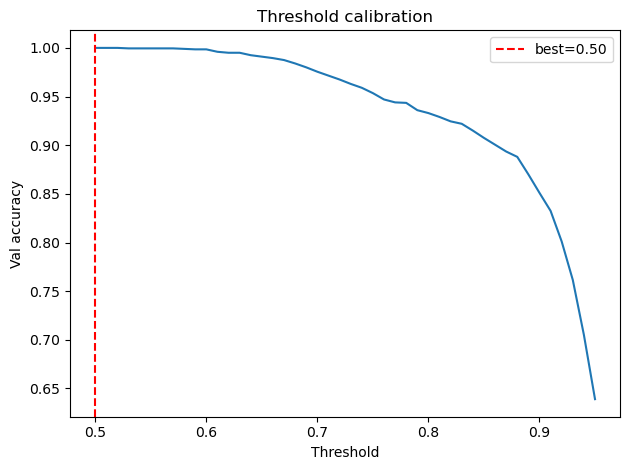

In [7]:
encoder = model.encoder.eval()

# --- Build prototype gallery from training samples ---

def embed_samples(sample_list):
    ds     = WriterDataset(sample_list, [0] * len(sample_list))
    loader = DataLoader(ds, batch_size=32)
    embs   = []
    with torch.no_grad():
        for xb, _ in loader:
            embs.append(encoder(xb.to(device)).cpu())
    return torch.cat(embs, dim=0)

gallery = {}
for writer_id, name in idx_to_writer.items():
    writer_samples = [samples_valid[i] for i in train_idx if labels_valid[i] == writer_id]
    if not writer_samples:
        continue
    embs  = embed_samples(writer_samples)
    proto = F.normalize(embs.mean(0, keepdim=True), p=2, dim=1).squeeze(0)
    gallery[name] = proto.cpu()

print("Gallery:", list(gallery.keys()))


# --- Predict a single sample ---

def predict(sample, threshold):
    x, _ = WriterDataset([sample], [0])[0]
    with torch.no_grad():
        emb = encoder(x.unsqueeze(0).to(device)).squeeze(0).cpu()
    best_name, best_sim = None, -1.0
    for name, proto in gallery.items():
        sim = float(torch.dot(emb, proto))
        if sim > best_sim:
            best_sim, best_name = sim, name
    return (best_name if best_sim >= threshold else "Unknown"), best_sim


# --- Calibrate threshold on validation set ---

thresholds = np.linspace(0.5, 0.95, 46)
accs = []
for thresh in thresholds:
    correct, total = 0, 0
    for i in val_idx:
        pred, _ = predict(samples_valid[i], thresh)
        if pred == idx_to_writer[labels_valid[i]]:
            correct += 1
        total += 1
    accs.append(correct / total)

best_thresh = float(thresholds[int(np.argmax(accs))])
best_acc    = max(accs)
print(f"Best threshold: {best_thresh:.2f}  →  val accuracy: {best_acc:.3f}")

plt.plot(thresholds, accs)
plt.axvline(best_thresh, color="red", linestyle="--", label=f"best={best_thresh:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Val accuracy")
plt.title("Threshold calibration"); plt.legend(); plt.tight_layout(); plt.show()


# --- Dynamically enroll a new writer (no retraining needed) ---

def enroll_new_writer(name: str, new_samples: list, momentum: float = 0.85):
    """Add or EMA-update a writer prototype in the gallery."""
    embs     = embed_samples(new_samples)
    new_proto = F.normalize(embs.mean(0, keepdim=True), p=2, dim=1).squeeze(0).cpu()
    if name in gallery:
        blended = momentum * gallery[name] + (1 - momentum) * new_proto
        gallery[name] = F.normalize(blended.unsqueeze(0), p=2, dim=1).squeeze(0)
    else:
        gallery[name] = new_proto
    print(f"Enrolled '{name}'  (gallery size: {len(gallery)})")

# Example:
# enroll_new_writer("alice", [some_sample_array, ...])

## Save as state dictionary or ONNX model

In [8]:
# Save encoder weights and normalization stats
torch.save(encoder.state_dict(), "style_encoder.pt")
np.save("style_channel_mean.npy", channel_mean)
np.save("style_channel_std.npy",  channel_std)

# Save gallery prototypes
torch.save({k: v.numpy() for k, v in gallery.items()}, "style_gallery.pt")

# ONNX export — input: (batch, channels=8, timesteps=96)
dummy = torch.randn(1, 8, TARGET_LEN, device=device)
torch.onnx.export(
    encoder,
    dummy,
    "style_encoder.onnx",
    input_names=["imu_data"],
    output_names=["style_embedding"],
    dynamic_axes={"imu_data": {0: "batch_size"}},
)
print("Saved: style_encoder.pt, style_channel_mean.npy, style_channel_std.npy, style_gallery.pt, style_encoder.onnx")

C:\Users\aidan\AppData\Local\Temp\ipykernel_34644\643107672.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `WriterEncoder([...]` with `torch.export.export(..., strict=False)`...


c:\Users\aidan\anaconda3\Lib\contextlib.py:162: UserWarning: The tensor attributes self.bigru._flat_weights[0], self.bigru._flat_weights[1], self.bigru._flat_weights[2], self.bigru._flat_weights[3], self.bigru._flat_weights[4], self.bigru._flat_weights[5], self.bigru._flat_weights[6], self.bigru._flat_weights[7] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  self.gen.throw(value)


[torch.onnx] Obtain model graph for `WriterEncoder([...]` with `torch.export.export(..., strict=False)`... ❌
[torch.onnx] Obtain model graph for `WriterEncoder([...]` with `torch.export.export(..., strict=True)`...
[torch.onnx] Obtain model graph for `WriterEncoder([...]` with `torch.export.export(..., strict=True)`... ✅
[torch.onnx] Run decomposition...


c:\Users\aidan\anaconda3\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 9 of general pattern rewrite rules.
Saved: style_encoder.pt, style_channel_mean.npy, style_channel_std.npy, style_gallery.pt, style_encoder.onnx
